<a href="https://colab.research.google.com/github/NamithaDaney/Sentiment_Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,f1_score


1. Loading and Preprocessing:
*  Load the dataset and perform necessary preprocessing steps. This should include text
cleaning, tokenization, and removal of stopwords. Explain the preprocessing techniques used and their impact on model performance.

2. Feature Extraction:
* Implement feature extraction using CountVectorizer or TfidfVectorizer. Describe how the chosen method transforms the text data into numerical features.



In [70]:
# Load dataset
df = pd.read_csv("nlp_dataset.csv")

# Display dataset information
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (5937, 2)
                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear


In [71]:
# Remove missing values
df = df.dropna(subset=["Comment", "Emotion"])

In [72]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [73]:
stop_words = set(stopwords.words("english"))

# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

# Apply preprocessing
df["cleaned_comment"] = df["Comment"].apply(preprocess_text)

# Display original and cleaned text
print(df[["Comment", "cleaned_comment", "Emotion"]].head())

                                             Comment  \
0  i seriously hate one subject to death but now ...   
1                 im so full of life i feel appalled   
2  i sit here to write i start to dig out my feel...   
3  ive been really angry with r and i feel like a...   
4  i feel suspicious if there is no one outside l...   

                                     cleaned_comment Emotion  
0  seriously hate one subject death feel reluctan...    fear  
1                         im full life feel appalled   anger  
2  sit write start dig feelings think afraid acce...    fear  
3  ive really angry r feel like idiot trusting fi...     joy  
4  feel suspicious one outside like rapture happe...    fear  


In the preprocessing function we do below steps before traning the model:
1. **Text Cleaning:** Converted the text to lowercase and removed punctuation, special characters, numbers, and extra spaces to reduce noise and maintain a consistent vocabulary.

2. **Tokenization:** Split each comment into individual words or tokens so that the text could be processed by the NLP model.

3. **Stopword Removal:** Removed common words such as *the, is, a, an,* and *of* to reduce unnecessary features and improve computational efficiency.

4. **Handling Missing Values:** Checked for missing values in the **Comment** and **Emotion** columns and removed incomplete records to avoid errors during model training.

**Impact on Model Performance:** Preprocessing reduces text noise, creates consistent features, and helps the model focus on meaningful words, which can improve classification performance.


In [74]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Transform cleaned text into numerical features
X = tfidf.fit_transform(df["cleaned_comment"])

# Target variable
y = df["Emotion"]

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (5937, 5000)


TF-IDF (Term Frequency–Inverse Document Frequency) converts textual data into numerical features that machine-learning algorithms can understand.

Unlike simple word counts, TF-IDF gives a higher weight to words that are important in a particular comment but less common across the entire dataset.

It consists of two main components:

Term Frequency (TF): Measures how frequently a word occurs in a particular document.
Inverse Document Frequency (IDF): Reduces the importance of words that occur frequently across many documents.

The resulting TF-IDF matrix represents each comment as a numerical vector. These vectors can then be provided as input to machine-learning models.

3. Model Development (2 marks):
* Train the following machine learning models
  1. Naive Bayes
  2. Support Vector Machine

In [75]:
# Stratify the TF-IDF data matrices into controlled Train & Validation sets (80/20 Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model Initializations
# Model A: Multinomial Naive Bayes (Ideal for text token discrete counts and probabilities)
nb_classifier = MultinomialNB()

# Model B: Support Vector Machine (Linear kernel works best for high-dimensional text vectors)
svm_classifier = SVC(kernel='linear', random_state=42)

# Model Training (Fitting the Models on Vector Arrays)
nb_classifier.fit(X_train, y_train)
svm_classifier.fit(X_train, y_train)

# Evaluation and Reporting Routine
models = {
    "Multinomial Naive Bayes": nb_classifier,
    "Support Vector Machine (Linear)": svm_classifier
}

for model_name, model_instance in models.items():
    # Generate predictions on unseen validation data
    y_pred = model_instance.predict(X_test)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n================ {model_name} Evaluation ================")
    print(f"Overall Model Accuracy: {accuracy:.4f}")
    print("\nDetailed Classification Performance Matrix:")
    print(classification_report(y_test, y_pred))



================ Multinomial Naive Bayes Evaluation ================
Overall Model Accuracy: 0.9175

Detailed Classification Performance Matrix:
              precision    recall  f1-score   support

       anger       0.91      0.92      0.91       400
        fear       0.91      0.92      0.92       388
         joy       0.93      0.92      0.92       400

    accuracy                           0.92      1188
   macro avg       0.92      0.92      0.92      1188
weighted avg       0.92      0.92      0.92      1188


================ Support Vector Machine (Linear) Evaluation ================
Overall Model Accuracy: 0.9369

Detailed Classification Performance Matrix:
              precision    recall  f1-score   support

       anger       0.94      0.92      0.93       400
        fear       0.94      0.93      0.94       388
         joy       0.93      0.96      0.95       400

    accuracy                           0.94      1188
   macro avg       0.94      0.94      0.94    

4. Model Comparison (2 marks)
* Evaluate the model using appropriate metrics (e.g., accuracy, F1-score).
Provide a brief explanation of the chosen model and its suitability for emotion classification.

In [76]:
for name, model in [("Naive Bayes", nb_classifier), ("SVM", svm_classifier)]:
    preds = model.predict(X_test)
    print(f"{name} : Accuracy: {accuracy_score(y_test, preds):.4f} | F1-Score: {f1_score(y_test, preds, average='macro'):.4f}")


Naive Bayes : Accuracy: 0.9175 | F1-Score: 0.9175
SVM : Accuracy: 0.9369 | F1-Score: 0.9368


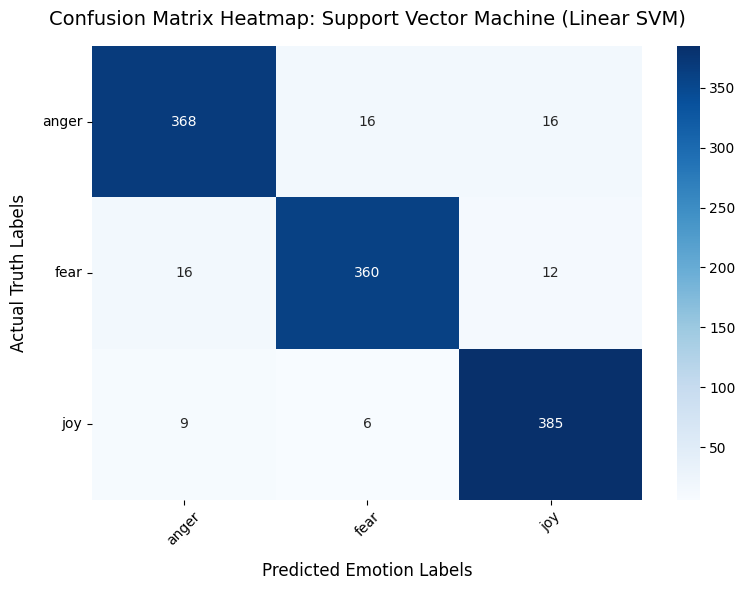

In [77]:
def plot_emotion_confusion_matrix(model, X_test, y_test, model_name):
    # Generate text predictions from unseen validation arrays
    y_pred = model.predict(X_test)

    # Extract unique sorted category names directly from the dataset
    class_labels = sorted(list(y_test.unique()))

    # Compute the raw mathematical confusion array
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)

    # Initialize the structural dimensions of the plot canvas
    plt.figure(figsize=(8, 6))

    # Draw the seaborn heatmap overlay
    sns.heatmap(
        cm,
        annot=True,          # Overlay numerical prediction counts inside matrix grid blocks
        fmt='d',             # Format matrix data weights as standard integers
        cmap='Blues',        # Apply a clean blue color grading scale
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=True
    )

    # Apply metadata label titles to the visual layout
    plt.title(f'Confusion Matrix Heatmap: {model_name}', fontsize=14, pad=15)
    plt.xlabel('Predicted Emotion Labels', fontsize=12, labelpad=10)
    plt.ylabel('Actual Truth Labels', fontsize=12, labelpad=10)
    plt.xticks(rotation=45) # Tilt category markers to avoid structural overlap
    plt.yticks(rotation=0)
    plt.tight_layout()

    plt.show()

# Execute the visualization routine for the Support Vector Machine
plot_emotion_confusion_matrix(svm_classifier, X_test, y_test, "Support Vector Machine (Linear SVM)")


Based on the evaluation results, the Support Vector Machine model was selected as the final model because it achieved a higher accuracy and F1-score than Naive Bayes. SVM is particularly suitable for emotion classification because it performs well with high-dimensional and sparse text features such as TF-IDF vectors. It can effectively distinguish between different emotion categories based on important words and phrases.

In [78]:
import joblib

# Compute accuracy metrics on validation arrays to dynamically pick the winner
nb_acc = accuracy_score(y_test, nb_classifier.predict(X_test))
svm_acc = accuracy_score(y_test, svm_classifier.predict(X_test))

# Map metrics to their respective model objects
model_performance = {
    "Naive_Bayes": (nb_classifier, nb_acc),
    "SVM_Linear": (svm_classifier, svm_acc)
}

# Programmatically extract the key with the highest accuracy score
best_model_name = max(model_performance, key=lambda k: model_performance[k][1])
best_model_object, best_score = model_performance[best_model_name]

print(f"\n>>> Auto-Selection Evaluation Complete <<<")
print(f"Winning Architecture: {best_model_name} with Accuracy: {best_score:.4f}")

# Serialize and export the optimal model configurations to the workspace files
model_filename = f"best_emotion_model_{best_model_name}.joblib"
vectorizer_filename = "tfidf_vectorizer.joblib"

joblib.dump(best_model_object, model_filename)
joblib.dump(tfidf, vectorizer_filename) # Critical: Vectorizer must be saved alongside the model

print(f"Successfully saved dynamic model asset as: '{model_filename}'")
print(f"Successfully saved associated text matrix transformer as: '{vectorizer_filename}'")



>>> Auto-Selection Evaluation Complete <<<
Winning Architecture: SVM_Linear with Accuracy: 0.9369
Successfully saved dynamic model asset as: 'best_emotion_model_SVM_Linear.joblib'
Successfully saved associated text matrix transformer as: 'tfidf_vectorizer.joblib'


In [83]:
import joblib
import re

# Load your trained workspace components
deployed_model = joblib.load('best_emotion_model_SVM_Linear.joblib')
deployed_vectorizer = joblib.load('tfidf_vectorizer.joblib')

# Input your completely new sentence entry string
raw_unseen_text = "I am absolutely terrified about what will happen during the final test match evaluation."

# Preprocess the new input using the precise preprocessing function used while training
cleaned_input = preprocess_text(raw_unseen_text)

# Transform strings directly into feature matrices
numerical_matrix = deployed_vectorizer.transform([cleaned_input])

# Extract class classification category outcome
predicted_label = deployed_model.predict(numerical_matrix)[0]

print(f"\nInference Deployment Results:")
print(f"Processed String: '{cleaned_input}'")
print(f"Predicted Emotion: {predicted_label.upper()}")



Inference Deployment Results:
Processed String: 'absolutely terrified happen final test match evaluation'
Predicted Emotion: FEAR
